# Decell Chicken Constructs — Actuation Analysis 2026-04-15

Two experiments:
- **Baseline**: `pyrroleDBS-baselineactuation.csv` + `pyrrole-baseline.mov` — 120 s applied voltage intervals
- **Decell chicken 1 soak**: `decel-chicken-1soakactuation.csv` + `decell_chicken_1_soak.mov` — 200 s applied voltage intervals

Pipeline:
1. Extract Force Out (V) from video via EasyOCR on raw color crop
2. Load current CSV
3. Synthesize applied voltage trace (±0.8 V steps)
4. Synchronize + merge all signals
5. Convert Force Out voltage → force (mN)
6. Plot + export

In [ ]:
import cv2
import numpy as np
import pandas as pd
import torch
import re
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Fine-tuned CNN trained on our XX.XXX display crops
from train_display_cnn import DisplayCNN, pad_resize, BLANK, N_SLOTS

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
_ckpt = torch.load('display_cnn.pt', map_location=device, weights_only=True)
cnn = DisplayCNN().to(device).eval()
cnn.load_state_dict(_ckpt['model'])
print(f'Display CNN loaded on {device}')

In [ ]:
# ── File paths ─────────────────────────────────────────────────────────────
DATA_DIR = Path('actuation_currents_data')

BASELINE_VIDEO  = DATA_DIR / '2026.4.15-pyrrole-baseline.mov'
BASELINE_CSV    = DATA_DIR / '2026.04.15-pyrroleDBS-baselineactuation.csv'
BASELINE_FORCE_CSV = DATA_DIR / '2026.4.15-pyrrole-baseline_force_cnn.csv'  # output

DECELL_VIDEO    = DATA_DIR / '2026.4.15-decell_chicken_1_soak.mov'
DECELL_CSV      = DATA_DIR / '2026.4.15-decel-chicken-1soakactuation.csv'
DECELL_FORCE_CSV = DATA_DIR / '2026.4.15-decell_chicken_1_soak_force_cnn.csv'  # output

# ── Per-experiment Force Out display crops ────────────────────────────────
# Camera position differed slightly between runs, so each video has its own
# crop. These match the crops used to train the CNN (see digit_knn.ipynb /
# train_display_cnn.py). n_digits is 4 for readings <10 V, 5 for ≥10 V.
BASELINE_CROP    = dict(y0=790, y1=884, x0=1175, x1=1415)
BASELINE_NDIGITS = 4

DECELL_CROP      = dict(y0=812, y1=909, x0=1095, x1=1372)
DECELL_NDIGITS   = 5

# ── Plausible voltage ranges per experiment ─────────────────────────────────
# Used to reject occasional CNN mis-reads before interpolation
BASELINE_V_MIN, BASELINE_V_MAX =  6.5,  9.0   # baseline resting ~7.6 V
DECELL_V_MIN,   DECELL_V_MAX   =  9.0, 14.0   # decell ~11.8 V at start

# ── Force calibration ───────────────────────────────────────────────────────
# Force (mN) = (force_V - FORCE_OFFSET_V) * FORCE_SCALE_mN_per_V
FORCE_SCALE_mN_per_V = 56    # ← ADJUST: mN per volt from device calibration
FORCE_OFFSET_V       = 0.0   # ← ADJUST: resting voltage at zero force

# ── Applied voltage protocol ────────────────────────────────────────────────
APPLIED_V_AMPLITUDE = 0.8
BASELINE_INTERVAL_S = 120
DECELL_INTERVAL_S   = 200

# ── Time sync offsets ───────────────────────────────────────────────────────
BASELINE_VIDEO_OFFSET_S = 0.0
DECELL_VIDEO_OFFSET_S   = 0.0

# ── Sampling rate (one frame every N seconds) ───────────────────────────────
OCR_DT_S = 0.5

## Step 1 — Extract Force Out (V) from video using the fine-tuned CNN

Each video frame's display crop is fed to the CNN, which outputs 5 digit slots
(blank + 0–9). Digits are concatenated and the decimal inserted 3 from the right.
Readings outside the plausible range are set to NaN and linearly interpolated.

In [ ]:
@torch.no_grad()
def predict_display_batch(crops_bgr):
    """List of H×W×3 BGR crops → list of voltage floats (or None)."""
    if not crops_bgr:
        return []
    imgs = np.stack([pad_resize(cv2.cvtColor(c, cv2.COLOR_BGR2RGB))
                     for c in crops_bgr])
    x = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().to(device) / 255.0
    preds = cnn(x).argmax(-1).cpu().numpy()   # (B, 5)
    return preds


def slots_to_voltage(slots, n_digits, v_min, v_max):
    """(5,) int slots → voltage float, or None if invalid."""
    # Leading slots (before the last n_digits) must be BLANK
    lead = slots[:N_SLOTS - n_digits]
    digs = slots[N_SLOTS - n_digits:]
    if any(d == BLANK for d in digs):
        return None
    if any(d != BLANK for d in lead):
        return None
    s = ''.join(str(int(d)) for d in digs)
    v = float(f'{int(s[:-3] or 0)}.{s[-3:]}')
    if not (v_min <= v <= v_max):
        return None
    return v


def extract_force_voltage(
    video_path: Path,
    output_csv: Path,
    crop: dict,
    n_digits: int,
    v_min: float,
    v_max: float,
    dt: float = OCR_DT_S,
    batch_size: int = 32,
) -> pd.DataFrame:
    """Run CNN on Force Out display and return a time-voltage DataFrame."""
    if output_csv.exists():
        print(f'{output_csv} already exists — loading cached result. Delete to re-run.')
        return pd.read_csv(output_csv)

    cap = cv2.VideoCapture(str(video_path))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dur   = total / fps
    print(f'{video_path.name}: {dur:.0f} s  |  {fps:.1f} fps  |  {total} frames')

    timestamps = np.arange(0, dur, dt)
    records = []

    buf_crops, buf_times = [], []

    def flush():
        if not buf_crops:
            return
        preds = predict_display_batch(buf_crops)
        for t, slots in zip(buf_times, preds):
            v = slots_to_voltage(slots, n_digits, v_min, v_max)
            records.append({'time_s': round(t, 3), 'force_V': v})
        buf_crops.clear(); buf_times.clear()

    for t in tqdm(timestamps, desc='CNN'):
        cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
        ret, frame = cap.read()
        if not ret:
            records.append({'time_s': round(t, 3), 'force_V': np.nan})
            continue
        buf_crops.append(frame[crop['y0']:crop['y1'], crop['x0']:crop['x1']])
        buf_times.append(t)
        if len(buf_crops) >= batch_size:
            flush()
    flush()
    cap.release()

    df = pd.DataFrame(records).sort_values('time_s').reset_index(drop=True)
    n_ok  = df['force_V'].notna().sum()
    n_bad = df['force_V'].isna().sum()
    print(f'CNN: {n_ok} ok  |  {n_bad} rejected ({100*n_bad/len(df):.1f}% NaN) — interpolating')
    df['force_V'] = df['force_V'].interpolate(method='linear', limit_direction='both')

    df.to_csv(output_csv, index=False)
    print(f'Saved → {output_csv}')
    return df

In [ ]:
# Run CNN on baseline video
df_baseline_force = extract_force_voltage(
    BASELINE_VIDEO, BASELINE_FORCE_CSV,
    crop=BASELINE_CROP, n_digits=BASELINE_NDIGITS,
    v_min=BASELINE_V_MIN, v_max=BASELINE_V_MAX,
)
df_baseline_force.head()

In [ ]:
# Run CNN on decell chicken 1-soak video
df_decell_force = extract_force_voltage(
    DECELL_VIDEO, DECELL_FORCE_CSV,
    crop=DECELL_CROP, n_digits=DECELL_NDIGITS,
    v_min=DECELL_V_MIN, v_max=DECELL_V_MAX,
)
df_decell_force.head()

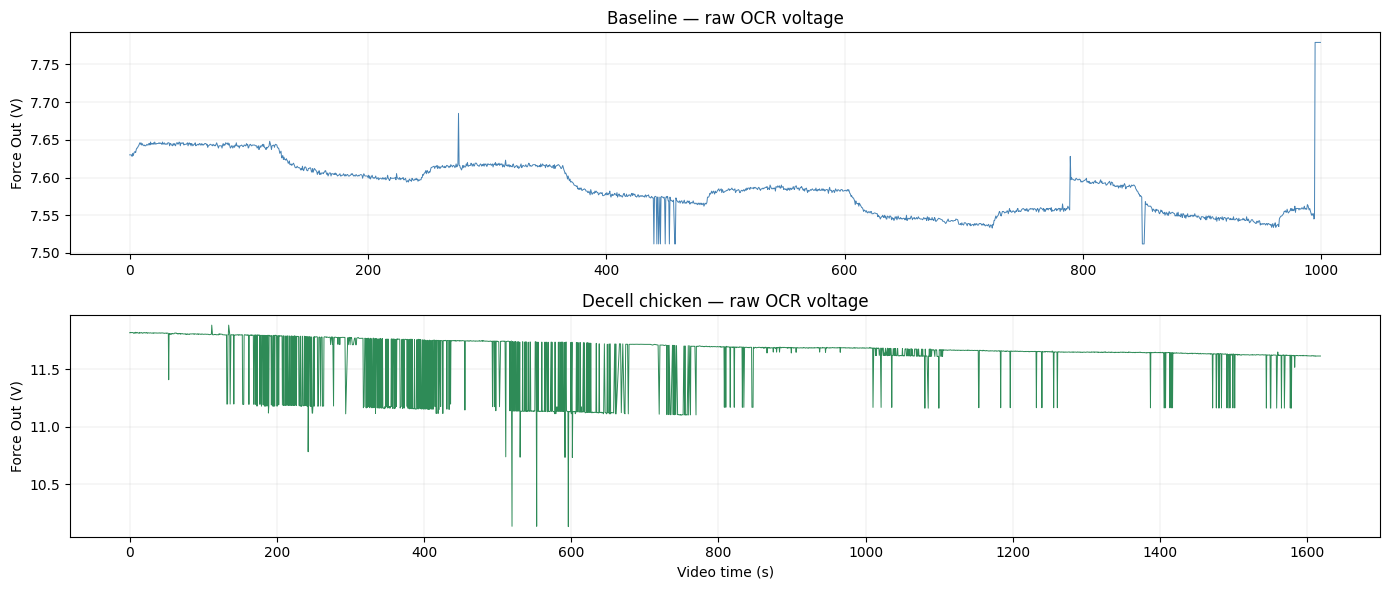

Baseline range: 7.512 – 7.779
Decell range:   10.133 – 11.882


In [6]:
# Quick sanity plot — check the OCR signals before merging
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(df_baseline_force['time_s'], df_baseline_force['force_V'],
             lw=0.7, color='steelblue')
axes[0].set(ylabel='Force Out (V)', title='Baseline — raw OCR voltage')
axes[0].grid(True, lw=0.3, alpha=0.5)

axes[1].plot(df_decell_force['time_s'], df_decell_force['force_V'],
             lw=0.7, color='seagreen')
axes[1].set(xlabel='Video time (s)', ylabel='Force Out (V)',
            title='Decell chicken — raw OCR voltage')
axes[1].grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

print('Baseline range:', df_baseline_force['force_V'].min(), '–', df_baseline_force['force_V'].max())
print('Decell range:  ', df_decell_force['force_V'].min(),   '–', df_decell_force['force_V'].max())

## Step 2 — Load current CSVs

In [7]:
def load_current_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding='utf-16', skiprows=5)
    df.columns = ['time_s', 'current_uA']
    df['time_s']     = pd.to_numeric(df['time_s'],     errors='coerce')
    df['current_uA'] = pd.to_numeric(df['current_uA'], errors='coerce')
    df = df.dropna().reset_index(drop=True)
    print(f'{path.name}: {len(df)} rows, t = {df.time_s.min():.1f} – {df.time_s.max():.1f} s')
    return df


df_baseline_current = load_current_csv(BASELINE_CSV)
df_decell_current   = load_current_csv(DECELL_CSV)

2026.04.15-pyrroleDBS-baselineactuation.csv: 9854 rows, t = 0.0 – 985.3 s
2026.4.15-decel-chicken-1soakactuation.csv: 16094 rows, t = 0.0 – 1609.3 s


## Step 3 — Synthesize applied voltage trace

Applied voltage steps ±0.8 V at fixed intervals:  
- **Baseline**: 120 s half-cycle → +0.8 V for 0–120 s, −0.8 V for 120–240 s, …  
- **Decell**: 200 s half-cycle

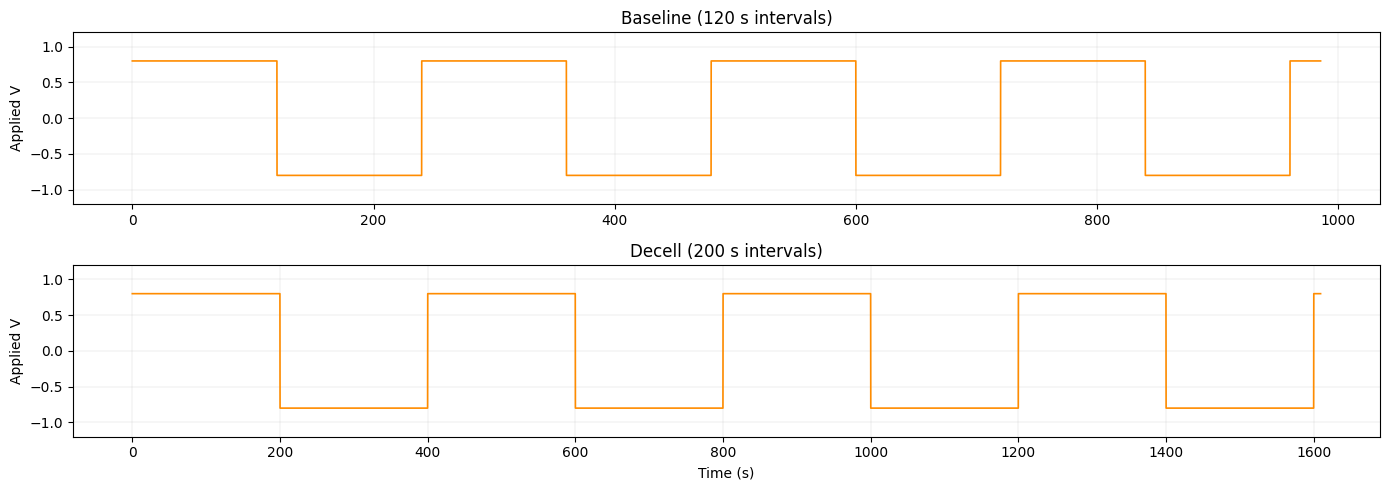

In [8]:
def make_applied_voltage(time_s: np.ndarray, interval_s: float,
                          amplitude: float = APPLIED_V_AMPLITUDE) -> np.ndarray:
    """Step function: +amplitude for first half-cycle, -amplitude for second, etc."""
    cycle = (time_s // interval_s).astype(int)
    return np.where(cycle % 2 == 0, +amplitude, -amplitude)


df_baseline_current['applied_V'] = make_applied_voltage(
    df_baseline_current['time_s'].values, BASELINE_INTERVAL_S)

df_decell_current['applied_V'] = make_applied_voltage(
    df_decell_current['time_s'].values, DECELL_INTERVAL_S)

# Quick check
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)
for ax, df, label in [
    (axes[0], df_baseline_current, 'Baseline (120 s intervals)'),
    (axes[1], df_decell_current,   'Decell (200 s intervals)'),
]:
    ax.plot(df['time_s'], df['applied_V'], lw=1.2, color='darkorange')
    ax.set(ylabel='Applied V', title=label, ylim=(-1.2, 1.2))
    ax.grid(True, lw=0.3, alpha=0.5)
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Step 4 — Synchronize and merge

Adjust `BASELINE_VIDEO_OFFSET_S` / `DECELL_VIDEO_OFFSET_S` until the force signal
step edges align with the applied voltage transitions in the combined plot below.

In [9]:
def merge_signals(df_current: pd.DataFrame, df_force: pd.DataFrame,
                   video_offset_s: float) -> pd.DataFrame:
    """Merge force voltage onto current dataframe using nearest-timestamp join."""
    df_f = df_force.copy()
    df_f['time_s'] = df_f['time_s'] + video_offset_s   # shift video timeline
    df_f = df_f.sort_values('time_s')

    df_c = df_current.sort_values('time_s')

    merged = pd.merge_asof(
        df_c,
        df_f.rename(columns={'time_s': 'time_s_video'}),
        left_on='time_s', right_on='time_s_video',
        direction='nearest',
        tolerance=1.0    # max 1 s gap
    )
    merged = merged.drop(columns=['time_s_video'], errors='ignore')
    n_matched = merged['force_V'].notna().sum()
    print(f'Merged: {n_matched}/{len(merged)} rows have force_V')
    return merged


df_baseline_merged = merge_signals(df_baseline_current, df_baseline_force,
                                   BASELINE_VIDEO_OFFSET_S)
df_decell_merged   = merge_signals(df_decell_current,   df_decell_force,
                                   DECELL_VIDEO_OFFSET_S)

Merged: 9854/9854 rows have force_V
Merged: 16094/16094 rows have force_V


## Step 5 — Force calibration

```
force_mN = (force_V - FORCE_OFFSET_V) × FORCE_SCALE_mN_per_V
```

Set `FORCE_OFFSET_V` to the resting Force Out voltage when no external force is applied  
(e.g. the baseline mean).  
Set `FORCE_SCALE_mN_per_V` from your Aurora Scientific calibration sheet.

In [10]:
for df in (df_baseline_merged, df_decell_merged):
    df['force_mN'] = (df['force_V'] - FORCE_OFFSET_V) * FORCE_SCALE_mN_per_V

## Step 6 — Final plots

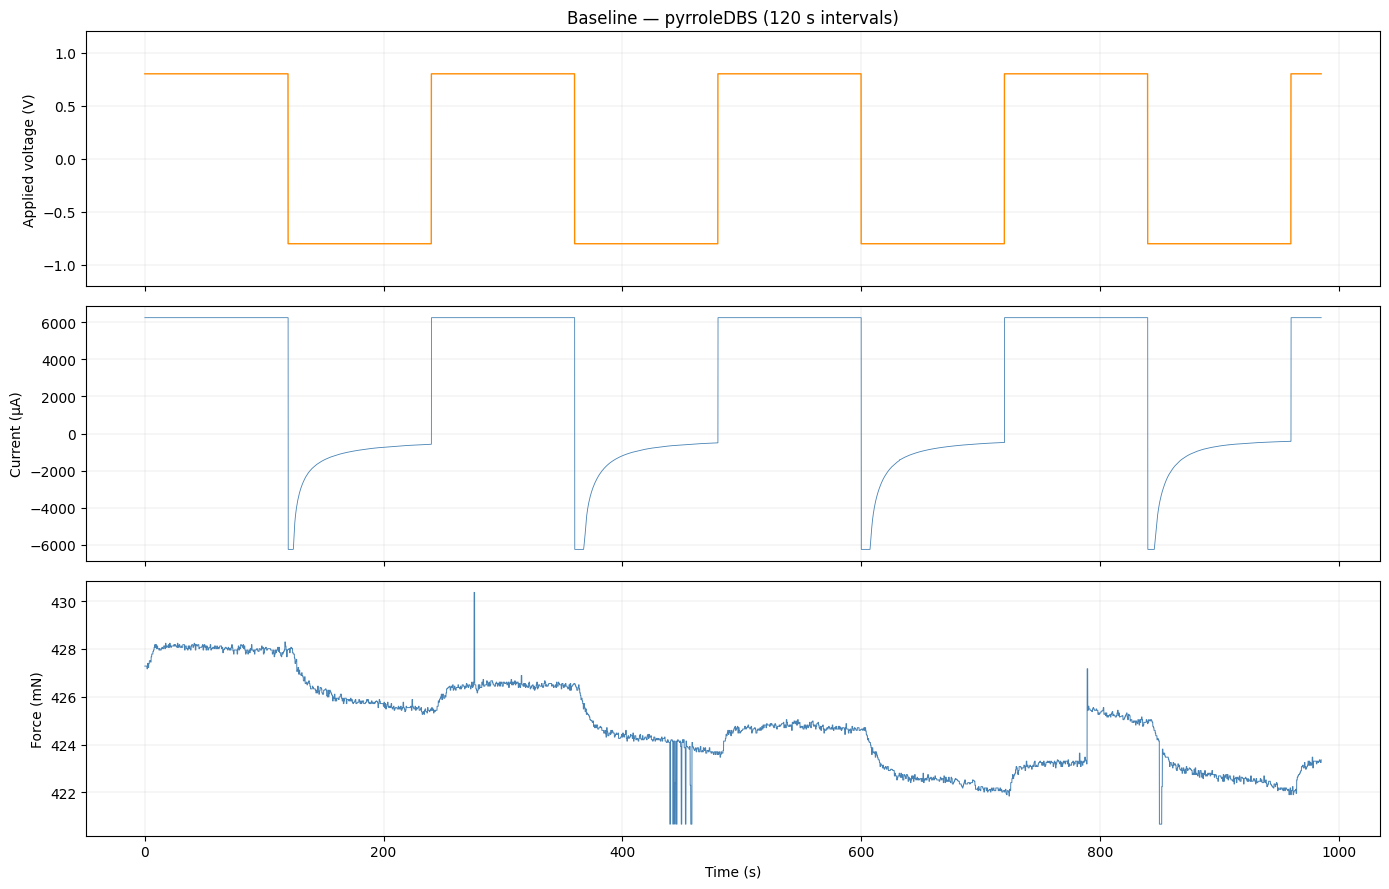

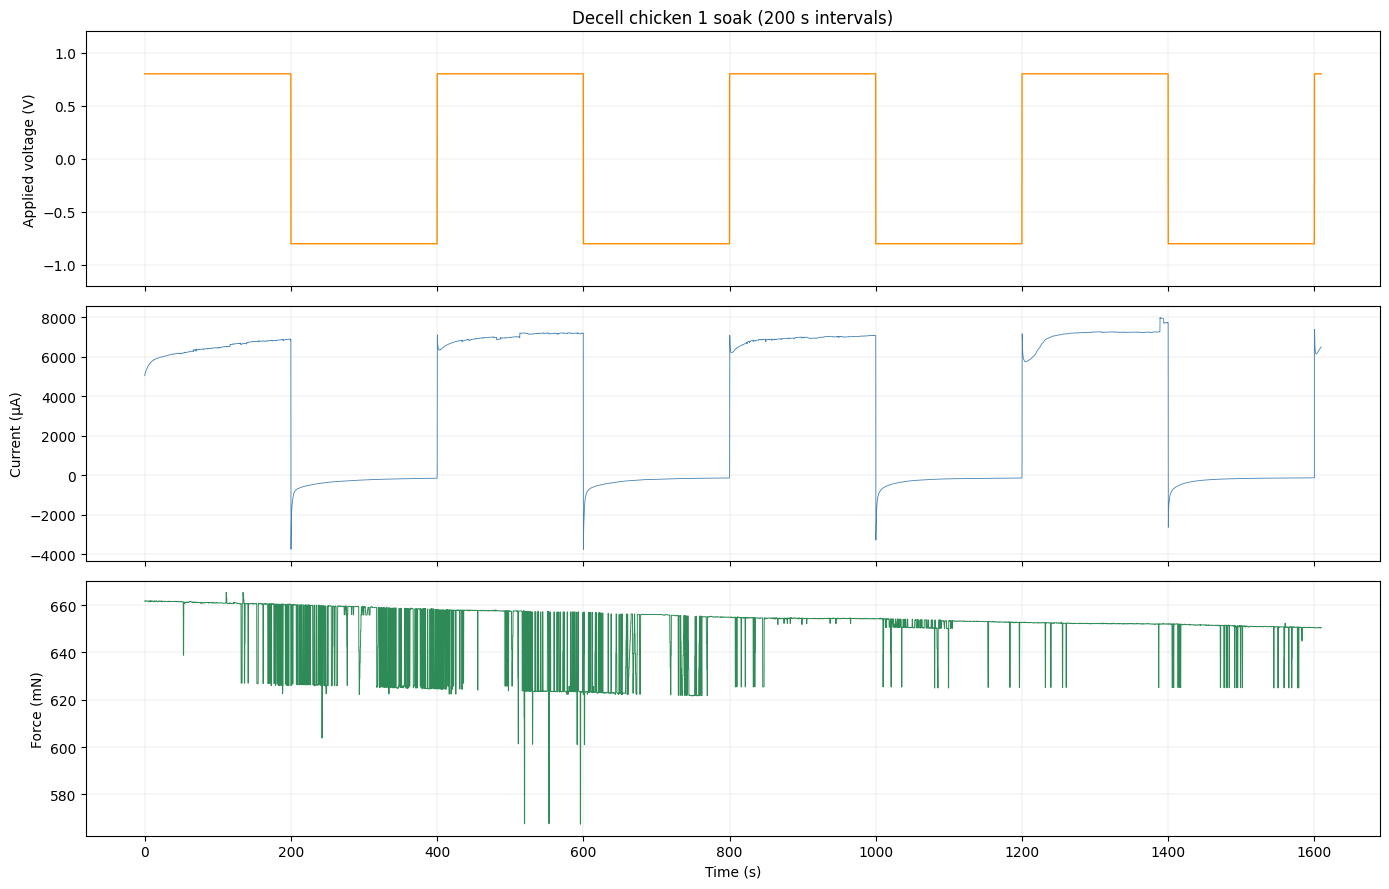

In [11]:
def plot_experiment(df: pd.DataFrame, title: str, color_force='seagreen',
                    color_current='steelblue', color_applied='darkorange'):
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(df['time_s'], df['applied_V'], lw=1.0, color=color_applied)
    axes[0].set(ylabel='Applied voltage (V)', title=title, ylim=(-1.2, 1.2))

    axes[1].plot(df['time_s'], df['current_uA'], lw=0.6, color=color_current)
    axes[1].set(ylabel='Current (µA)')

    axes[2].plot(df['time_s'], df['force_mN'], lw=0.7, color=color_force)
    axes[2].set(xlabel='Time (s)', ylabel='Force (mN)')

    for ax in axes:
        ax.grid(True, lw=0.3, alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_experiment(df_baseline_merged,
                'Baseline — pyrroleDBS (120 s intervals)',
                color_force='steelblue')

plot_experiment(df_decell_merged,
                'Decell chicken 1 soak (200 s intervals)',
                color_force='seagreen')

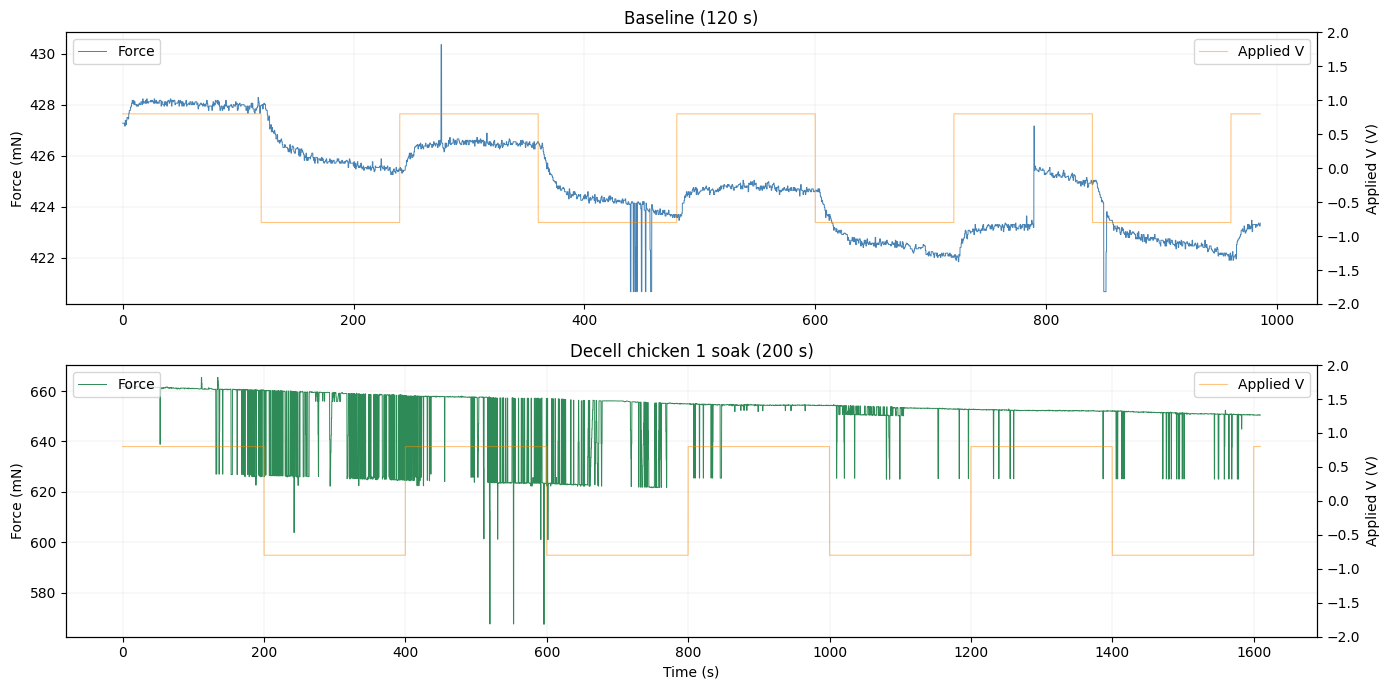

In [12]:
# Overlay: force vs applied voltage — both experiments
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, df, label, c in [
    (axes[0], df_baseline_merged, 'Baseline (120 s)', 'steelblue'),
    (axes[1], df_decell_merged,   'Decell chicken 1 soak (200 s)', 'seagreen'),
]:
    ax2 = ax.twinx()
    ax.plot(df['time_s'], df['force_mN'],   lw=0.7, color=c,            label='Force')
    ax2.plot(df['time_s'], df['applied_V'], lw=0.8, color='darkorange',  alpha=0.5, label='Applied V')
    ax.set(ylabel='Force (mN)', title=label)
    ax2.set(ylabel='Applied V (V)', ylim=(-2, 2))
    ax.legend(loc='upper left');  ax2.legend(loc='upper right')
    ax.grid(True, lw=0.3, alpha=0.4)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Step 7 — Export merged CSVs

In [13]:
baseline_out = DATA_DIR / '2026.4.15-pyrrole-baseline_merged.csv'
decell_out   = DATA_DIR / '2026.4.15-decell_chicken_1_soak_merged.csv'

df_baseline_merged.to_csv(baseline_out, index=False)
df_decell_merged.to_csv(decell_out, index=False)

print(f'Saved → {baseline_out}')
print(f'Saved → {decell_out}')
df_baseline_merged.describe()

Saved → actuation_currents_data/2026.4.15-pyrrole-baseline_merged.csv
Saved → actuation_currents_data/2026.4.15-decell_chicken_1_soak_merged.csv


,time_s,current_uA,applied_V,force_V,force_mN
count,9854.000000,9854.000000,9854.000000,9854.000000,9854.000000
mean,492.650000,2512.385824,0.020621,7.585655,424.796684
std,284.474911,3969.341009,0.799775,0.032973,1.846462
min,0.000000,-6250.000000,-0.800000,7.512000,420.672000
25%,246.325000,-799.384750,-0.800000,7.555000,423.080000
50%,492.650000,6250.000000,0.800000,7.584000,424.704000
75%,738.975000,6250.000000,0.800000,7.613000,426.328000
max,985.300000,6250.000000,0.800000,7.685000,430.360000
